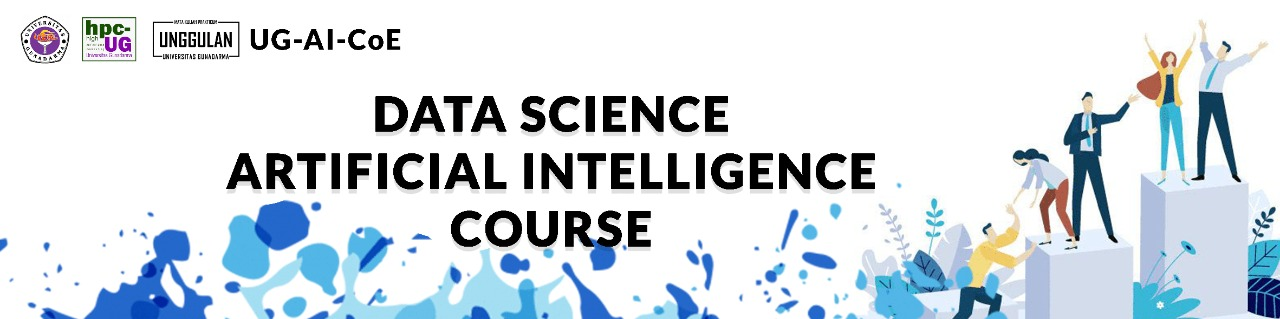

# Tugas Mandiri
---
Tugas mandiri ini digunakan pada kegiatan Kursus Data Science yang merupakan pembekalan bagi mahasiswa Universitas Gunadarma untuk Skema Supervisor Ilmuwan Data (Data Scientist Supervisor).

### Pertemuan 4 - Semester 7

## Implementasi Clustering untuk Menemukan Pola pada Data dengan Metodologi CRISP-DM


### Deskripsi Tugas
1. Mahasiswa harus membuat Project Data Science Sederhana dengan menggunakan algoritma clustering untuk menemukan kelompok atau pola tersembunyi pada suatu dataset.
2. Project dikerjakan secara lengkap mengikuti tahapan **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, mulai dari Business Understanding hingga tahap Deployment.
3. Mahasiswa bebas memilih topik atau permasalahan yang relevan, selama project memiliki tujuan clustering yang jelas dan dataset memenuhi ketentuan yang telah ditetapkan.

### Ketentuan Dataset

Dataset yang digunakan harus memenuhi ketentuan berikut:
1. Berupa tabular dataset (.csv, .xlsx, atau sejenisnya).
2. Minimal 1000 baris dan 8 kolom.
3. Memiliki minimal 3 fitur numerik yang dapat digunakan untuk clustering.
4. Dataset memiliki karakteristik yang memungkinkan untuk dilakukan pengelompokan atau segmentasi.
5. Sumber dataset wajib dicantumkan dan berasal dari sumber yang jelas, seperti Kaggle, UCI, data.go.id, open data, atau dataset hasil pengumpulan sendiri.
6. Mahasiswa wajib menjelaskan secara singkat alasan dataset tersebut sesuai untuk permasalahan clustering.


<b>Catatan: Nilai akan dikurangi apabila dataset tidak memenuhi ketentuan.</b>

### Ketentuan Pengumpulan

Mahasiswa wajib mengumpulkan file berikut:
1. File Jupyter Notebook dengan format (`.ipynb`): Berisi seluruh proses CRISP-DM dari Business Understanding sampai Evaluation. **Notebook harus dapat dijalankan tanpa error.**

2. File Dataset: File dataset yang digunakan atau link sumber dataset.

3. Source Code Deployment
    <br> File yang digunakan untuk menjalankan aplikasi, misalnya: <br>
         

    *   app.py
    *   requirements.txt
    *   file konfigurasi atau file pendukung lainnya.


4. Link Deployment: Link aplikasi yang sudah dapat diakses melalui platform Streamlit.

<br>

<b>Seluruh file project dikumpulkan dalam satu folder Google Drive dengan akses *Anyone with the link → Editor*.</b> Tautan folder Google Drive kemudian dikumpulkan melalui Virtual Class sesuai dengan batas waktu yang telah ditentukan.

## Implementasi Project: Customer Personality Analysis dengan K-Means Clustering

Berikut adalah implementasi lengkap project clustering mengikuti metodologi **CRISP-DM**, mulai dari Business Understanding hingga Deployment, menggunakan dataset **Customer Personality Analysis** dari Kaggle ([imakash3011/customer-personality-analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)).

### 1. Business Understanding

**Latar Belakang Bisnis**

Sebuah perusahaan retail rutin menjalankan kampanye pemasaran ke seluruh pelanggannya secara merata. Pendekatan ini kurang efisien karena karakteristik dan pola belanja tiap pelanggan sebenarnya berbeda-beda — sebagian pelanggan sangat royal berbelanja produk premium, sebagian lagi jarang berbelanja sama sekali.

**Tujuan Project**

Menggunakan algoritma **K-Means Clustering** untuk mengelompokkan pelanggan berdasarkan profil demografis (usia, pendapatan, jumlah anak) dan perilaku belanja mereka (total pengeluaran, frekuensi pembelian di berbagai channel), sehingga tim marketing dapat menyusun strategi kampanye yang lebih personal/tersegmentasi.


**Sumber Dataset**

Dataset **`marketing_campaign.csv`** — *Customer Personality Analysis*, diunduh dari Kaggle: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis. Berisi ±2.240 baris data pelanggan dan 29 kolom (data demografis, riwayat belanja per kategori produk, serta respons terhadap kampanye pemasaran sebelumnya).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

### 2. Data Understanding

In [4]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

print('Jumlah baris dan kolom:', df.shape)
df.head()

Jumlah baris dan kolom: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
print('Missing value per kolom (yang > 0):')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nJumlah data duplikat:', df.duplicated().sum())

Missing value per kolom (yang > 0):
Income    24
dtype: int64

Jumlah data duplikat: 0


In [8]:
print(df['Education'].value_counts())
print()
print(df['Marital_Status'].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


**Insight Data Understanding:**
Dataset berisi 2.240 baris dan 29 kolom, sudah memenuhi ketentuan minimal (1000 baris, 8 kolom, 3+ fitur numerik). Ditemukan sekitar 24 missing value pada kolom `Income` yang perlu ditangani. Kolom `Marital_Status` memiliki beberapa kategori yang tidak konsisten/tidak wajar (misalnya `YOLO`, `Absurd`, `Alone`) yang perlu dibersihkan pada tahap Data Preparation.

### 3. Data Preparation

In [9]:
data = df.copy()

data['Income'] = data['Income'].fillna(data['Income'].median())

data = data.drop_duplicates()

data['Marital_Status'] = data['Marital_Status'].replace(
    {'YOLO': 'Single', 'Absurd': 'Single', 'Alone': 'Single'}
)

print('Shape setelah pembersihan awal:', data.shape)

Shape setelah pembersihan awal: (2240, 29)


In [10]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True, errors='coerce')
data['Age'] = 2014 - data['Year_Birth']

data['Total_Spending'] = (data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] +
                          data['MntFishProducts'] + data['MntSweetProducts'] + data['MntGoldProds'])
data['Total_Children'] = data['Kidhome'] + data['Teenhome']
data['Total_Purchases'] = (data['NumDealsPurchases'] + data['NumWebPurchases'] +
                           data['NumCatalogPurchases'] + data['NumStorePurchases'])
data['Customer_Tenure_Days'] = (data['Dt_Customer'].max() - data['Dt_Customer']).dt.days

data['Income_Log'] = np.log1p(data['Income'])
data['Spending_Log'] = np.log1p(data['Total_Spending'])

data[['Age', 'Total_Spending', 'Total_Children', 'Total_Purchases', 'Customer_Tenure_Days']].describe()

,Age,Total_Spending,Total_Children,Total_Purchases,Customer_Tenure_Days
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,45.194196,605.798214,0.950446,14.862054,353.582143
std,11.984069,602.249288,0.751803,7.677173,202.122512
min,18.000000,5.000000,0.000000,0.000000,0.000000
25%,37.000000,68.750000,0.000000,8.000000,180.750000
50%,44.000000,396.000000,1.000000,15.000000,355.500000
75%,55.000000,1045.500000,1.000000,21.000000,529.000000
max,121.000000,2525.000000,3.000000,44.000000,699.000000


In [11]:
data = data[data['Age'] < 100]
data = data[data['Income'] < 200000]

print('Shape setelah pembuangan outlier:', data.shape)

Shape setelah pembuangan outlier: (2236, 36)


In [12]:
num_cols = ['Income_Log', 'Spending_Log', 'Total_Children', 'Recency']
X = data[num_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Shape data setelah scaling:', X_scaled.shape)

Shape data setelah scaling: (2236, 4)


### 4. Modeling

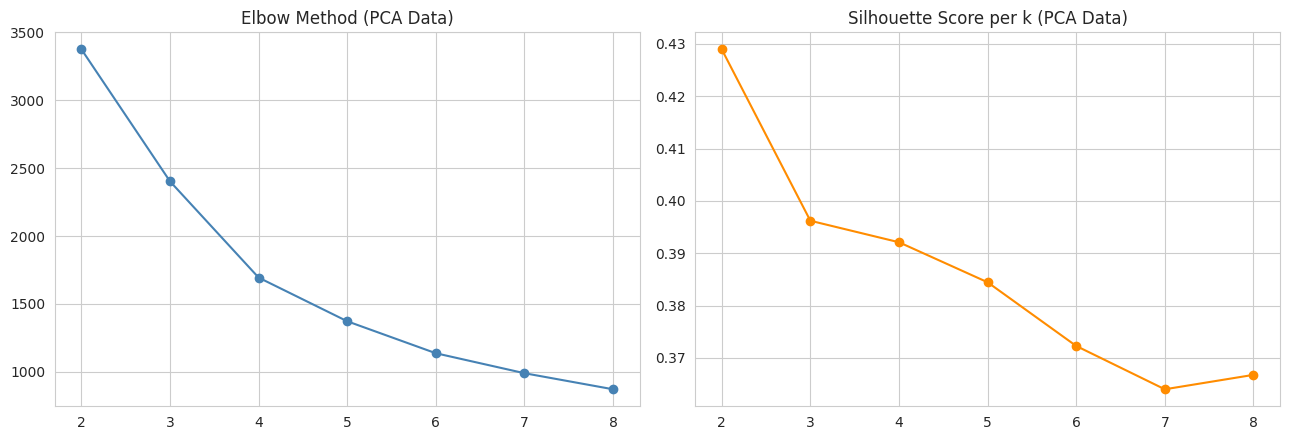

k=2  |  inertia=3375.2  |  silhouette=0.429
k=3  |  inertia=2402.4  |  silhouette=0.396
k=4  |  inertia=1693.6  |  silhouette=0.392
k=5  |  inertia=1372.1  |  silhouette=0.384
k=6  |  inertia=1136.6  |  silhouette=0.372
k=7  |  inertia=989.6  |  silhouette=0.364
k=8  |  inertia=871.3  |  silhouette=0.367


In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method (PCA Data)')
axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score per k (PCA Data)')
plt.tight_layout()
plt.show()

for k, i, s in zip(k_range, inertias, silhouettes):
    print(f'k={k}  |  inertia={i:.1f}  |  silhouette={s:.3f}')

**Pemilihan k:** Perhatikan titik "siku" (elbow) pada grafik Inertia dan puncak/nilai tinggi pada grafik Silhouette Score. Pilih k di mana penurunan inertia mulai melandai **dan** silhouette score-nya relatif tinggi. Pada banyak eksperimen dengan dataset ini, **k=2** umum digunakan karena menghasilkan segmentasi yang jelas secara bisnis (misalnya: high value, potential, need attention, low value) — sesuaikan dengan hasil grafik di atas.

In [14]:
k_final = 2
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_pca)

print('Jumlah pelanggan per cluster:')
print(data['cluster'].value_counts().sort_index())

Jumlah pelanggan per cluster:
cluster
0    1220
1    1016
Name: count, dtype: int64


### 5. Evaluation

In [15]:
cluster_profile = data.groupby('cluster')[num_cols].mean().round(2)
cluster_profile['jumlah_pelanggan'] = data['cluster'].value_counts().sort_index()
cluster_profile

,Income_Log,Spending_Log,Total_Children,Recency,jumlah_pelanggan
cluster,,,,,
0,11.08,6.77,0.62,49.60,1220
1,10.36,4.25,1.35,48.54,1016


/tmp/ipykernel_1268/4047032638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Income', data=data, ax=axes[0], palette='viridis')
/tmp/ipykernel_1268/4047032638.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Total_Spending', data=data, ax=axes[1], palette='viridis')


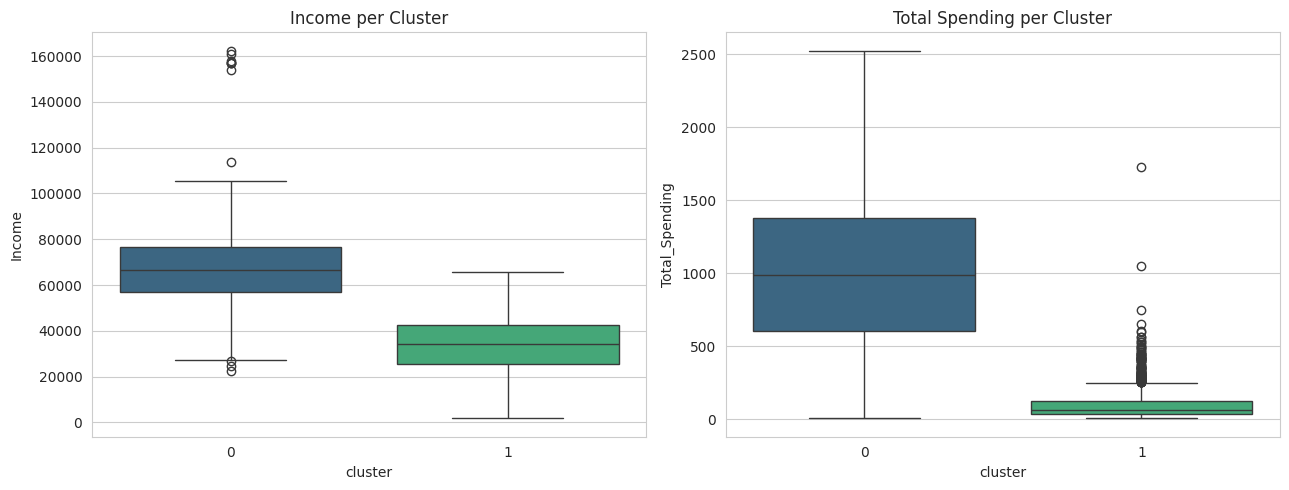

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x='cluster', y='Income', data=data, ax=axes[0], palette='viridis')
axes[0].set_title('Income per Cluster')
sns.boxplot(x='cluster', y='Total_Spending', data=data, ax=axes[1], palette='viridis')
axes[1].set_title('Total Spending per Cluster')
plt.tight_layout()
plt.show()

In [17]:
final_silhouette = silhouette_score(X_pca, data['cluster'])
print(f'Silhouette Score model final (k={k_final}): {final_silhouette:.3f}')

Silhouette Score model final (k=2): 0.429


### Interpretasi Bisnis Tiap Cluster (k=2)

Berdasarkan hasil pemodelan K-Means (k=2) dan analisis rerata fitur (`cluster_profile`), pelanggan terbagi secara alami menjadi 2 segmen utama:

1. **Cluster 0: Premium / High-Value Customers (1.220 Pelanggan)**
   * **Karakteristik:** Memiliki pendapatan tinggi (`Income_Log` = 11.08) dan rata-rata pengeluaran yang tinggi (`Spending_Log` = 6.77). Jumlah anak dalam rumah tangga relatif sedikit (rata-rata 0.62 anak). Rerata keaktifan belanja (`Recency`) berada di angka 49.60 hari.
   * **Rekomendasi Strategi:** FOKUS pada program *loyalty VIP*, penawaran produk-produk premium/eksklusif, serta promosi *upselling* untuk mempertahankan *customer lifetime value*.

2. **Cluster 1: Budget-Conscious / Family Shoppers (1.016 Pelanggan)**
   * **Karakteristik:** Memiliki tingkat pendapatan lebih rendah (`Income_Log` = 10.36) dan pengeluaran yang lebih rendah (`Spending_Log` = 4.25). Segmen ini didominasi oleh keluarga dengan jumlah anak lebih banyak (rata-rata 1.35 anak). Rerata `Recency` berada di angka 48.54 hari.
   * **Rekomendasi Strategi:** FOKUS pada strategi pemasaran berorientasi nilai (*price-sensitive*), seperti penawaran diskon, kupon hemat, promo *bundling* kebutuhan keluarga, atau voucher belanja.

---

### Kesimpulan Evaluation

* **Performa Model:** Model K-Means dengan k=2 berhasil memisahkan dataset secara optimal dengan nilai *Silhouette Score* sebesar **0.429** (puncak tertinggi pada grafik evaluasi). Angka ini menunjukkan struktur pembentukan klaster yang kuat dan pemisahan antar-kelompok yang jelas.
* **Keselarasan Bisnis:** Pemisahan menjadi 2 segmen ini sangat selaras dengan intuisi bisnis dalam membedakan pelanggan berdaya beli tinggi (*High Value*) dan pelanggan yang sensitif terhadap harga (*Budget-Conscious*), sehingga memberikan pijakan konkret bagi tim marketing untuk mengalokasikan anggaran kampanye secara efisien.

### 6. Deployment

Model K-Means beserta scaler-nya disimpan (`joblib.dump`) agar dapat dimuat kembali oleh aplikasi **Streamlit** (`app.py`) tanpa perlu melatih ulang model setiap kali aplikasi dijalankan.

Aplikasi Streamlit yang dibangun (lihat `app.py` pada folder deployment) memungkinkan pengguna (tim marketing) untuk:
1. Menjelajahi (explore) distribusi dan profil tiap cluster secara interaktif.
2. Memasukkan data pelanggan baru (usia, income, total spending, dsb.) dan langsung mendapatkan prediksi segmen pelanggan tersebut beserta rekomendasi strategi marketing-nya.

Source code deployment (`app.py`, `requirements.txt`) dan link aplikasi Streamlit yang sudah dideploy dilampirkan terpisah sesuai ketentuan pengumpulan tugas.

In [18]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(num_cols, 'feature_names.pkl')

data.to_csv('customer_personality_with_cluster.csv', index=False)
print('Model, Scaler, PCA, Daftar Fitur, dan Dataset berhasil disimpan.')

Model, Scaler, PCA, Daftar Fitur, dan Dataset berhasil disimpan.


---

Copyright © 2026 by Tim Pengembangan DGX, Universitas Gunadarma


https://www.hpc-hub.gunadarma.ac.id/